In [1]:
import requests
import urllib3
import warnings

# Suppress the obnoxious warnings we are about to generate
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", message="Unverified HTTPS request")

# Monkeypatch the requests library to bypass SSL verification
old_request = requests.Session.request

def new_request(self, method, url, **kwargs):
    kwargs['verify'] = False
    return old_request(self, method, url, **kwargs)

requests.Session.request = new_request

print("SSL Verification Disabled. Ready to download.")

SSL Verification Disabled. Ready to download.


## Setup and Load

In [2]:
import sys
from pathlib import Path
import plotly.graph_objects as go
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.data_loader import EnergyDataLoader
from src.forecaster import TSFMForecaster

# Load data using our class from Step 2
loader = EnergyDataLoader('../data/electricity_cleaned.csv')
df = loader.load_and_clean(target_building_id='Fox_education_Ollie')
print("Data loaded and cleaned. Here's a preview:")
print(df.head())

# Define our problem: We will give the model 2 weeks of context to predict the next 48 hours
context_length = 24 * 14
prediction_length = 48

# Slice a specific window from the dataset for this experiment
experiment_end_date = '2016-09-15 23:00:00'
historical_data = df.loc[:experiment_end_date].tail(context_length)
print(f"Using historical data from {historical_data.index[0]} to {historical_data.index[-1]} for context.")

# The "ground truth" (what actually happened) so we can check the model's accuracy later
actual_future = df.loc[experiment_end_date:].iloc[1:prediction_length + 1]
print(f"Actual future data from {actual_future.index[0]} to {actual_future.index[-1]} ready for evaluation.")

Loading data from ../data/electricity_cleaned.csv...
Loaded 17544 hourly records for building: Fox_education_Ollie
Data loaded and cleaned. Here's a preview:
                     energy_kwh
datetime                       
2016-01-01 00:00:00       77.61
2016-01-01 01:00:00       75.83
2016-01-01 02:00:00       80.57
2016-01-01 03:00:00       81.53
2016-01-01 04:00:00       83.55
Using historical data from 2016-09-02 00:00:00 to 2016-09-15 23:00:00 for context.
Actual future data from 2016-09-16 00:00:00 to 2016-09-17 23:00:00 ready for evaluation.


## Run the Model

In [3]:
# Initialize and predict
forecaster = TSFMForecaster(model_id="amazon/chronos-t5-small")
forecast_df = forecaster.predict(historical_data['energy_kwh'], prediction_length=prediction_length)

forecast_df.head()

Loading Time Series Foundation Model: amazon/chronos-t5-small...
Generating 48-hour forecast...


,forecast_low_p10,forecast_median,forecast_high_p90
datetime,,,
2016-09-16 00:00:00,92.351926,99.065453,100.866648
2016-09-16 01:00:00,90.059502,97.018646,104.141535
2016-09-16 02:00:00,90.878227,97.837368,101.030392
2016-09-16 03:00:00,89.895757,97.837368,102.504092
2016-09-16 04:00:00,90.059502,95.381203,99.966051


## Visualize
Here we plot the historical context (blue), the actual future energy use (green), and the Foundation Model's zero-shot prediction (orange line with shaded confidence interval). Notice how well it captures the daily peak without any specific training.

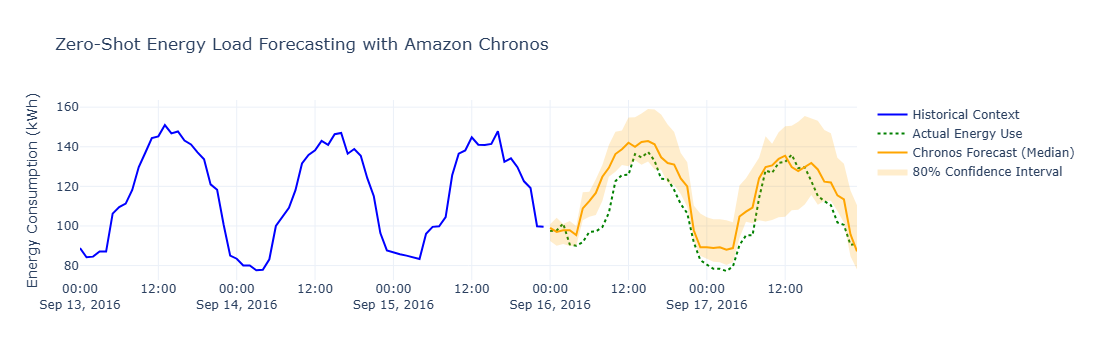

In [4]:
fig = go.Figure()

# Plot Historical Context
fig.add_trace(go.Scatter(
    x=historical_data.tail(24*3).index, # Just plotting the last 3 days for a cleaner visual
    y=historical_data.tail(24*3)['energy_kwh'],
    mode='lines',
    name='Historical Context',
    line=dict(color='blue')
))

# Plot Actual Future (Ground Truth)
fig.add_trace(go.Scatter(
    x=actual_future.index,
    y=actual_future['energy_kwh'],
    mode='lines',
    name='Actual Energy Use',
    line=dict(color='green', dash='dot')
))

# Plot Forecast Median
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df['forecast_median'],
    mode='lines',
    name='Chronos Forecast (Median)',
    line=dict(color='orange')
))

# Plot Confidence Interval
fig.add_trace(go.Scatter(
    x=list(forecast_df.index) + list(forecast_df.index)[::-1],
    y=list(forecast_df['forecast_high_p90']) + list(forecast_df['forecast_low_p10'])[::-1],
    fill='toself',
    fillcolor='rgba(255, 165, 0, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    name='80% Confidence Interval'
))

fig.update_layout(
    title='Zero-Shot Energy Load Forecasting with Amazon Chronos',
    yaxis_title='Energy Consumption (kWh)',
    template='plotly_white'
)
fig.show()